In [8]:
'''
Instructions:
You are tasked with building a robust machine learning model to predict salaries based on years of experience. This time, you must use Gradient Descent with Backtracking Line Search. Unlike previous homework, you’ll also analyze its behavior under multiple conditions.

Dataset:

import numpy as np

# Dataset: Years of Experience vs Salary (in thousands of ₹ per month)
years_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7])
salary_k = np.array([39, 46, 37, 43, 39, 56, 60, 54, 63, 55])
Steps

Part A: Core Implementation (40%)

    Data Preparation
    Normalize the years_experience feature.
    Initialize model parameters: m = 0, c_intercept = 0.
    Set backtracking parameters:
    Initial step size: alpha = 1.0
    Shrink factor: rho = 0.5
    Acceptance constant: c_param = 1e-4
    Implement Gradient Descent with Backtracking
    Run for 100 iterations.

    Each iteration should:
        Propose a step size (start with current alpha).
        Use a while loop for backtracking to shrink until cost decreases sufficiently.
        Update m and c_intercept.
        Track costs for visualization.
        Final Model Fit
        Print optimized m and c_intercept.
        Plot scatter of data + best-fit line.
Part B: Error Analysis (20%)

    Calculate residuals (actual - predicted).
    Plot a histogram of residuals.
    Write 2–3 sentences interpreting the results:
    Are residuals centered near zero?
    Are there signs of bias?
Part C: Backtracking Behavior (20%)

    Count the total number of backtracking while loop executions across all iterations.
    Run your code twice:
    Case 1: Initial alpha = 1.0
    Case 2: Initial alpha = 0.1
    Compare results:
    Does the total number of backtracking steps increase or decrease?
    Why do you think this happens? (Write 3–4 sentences).
Part D: Robustness Challenge (20%)

    Add Outliers to the Dataset:
        (10 years, ₹300k)
        (12 years, ₹500k)
    Re-run Gradient Descent with Backtracking on the new dataset.
    Compare:
        Original vs New best-fit line (plot both on the same graph).
        Comment: How do outliers affect your model?
        Suggest one method to reduce the impact of outliers (e.g., robust regression or feature scaling).
Deliverables:
    Submit your Google Colab notebook containing:

        Complete code implementation.
        Salary prediction line plot (with & without outliers).
        Residuals histogram.
        Backtracking loop counts & comparison.
        Written answers for interpretation questions.
Bonus Question (Optional – 10% Extra Credit)

    Implement a version of Gradient Descent with fixed learning rate = 0.01 on the same dataset.
    Compare its performance (iterations to convergence, final cost) with Backtracking GD.
    Plot both cost curves on the same graph.
    Write a short conclusion: Which method would you trust more in real-world ML, and why?
'''

'\nInstructions:\nYou are tasked with building a robust machine learning model to predict salaries based on years of experience. This time, you must use Gradient Descent with Backtracking Line Search. Unlike previous homework, you’ll also analyze its behavior under multiple conditions.\n\nDataset:\n\nimport numpy as np\n\n# Dataset: Years of Experience vs Salary (in thousands of ₹ per month)\nyears_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7])\nsalary_k = np.array([39, 46, 37, 43, 39, 56, 60, 54, 63, 55])\nSteps\n\nPart A: Core Implementation (40%)\n\n    Data Preparation\n    Normalize the years_experience feature.\n    Initialize model parameters: m = 0, c_intercept = 0.\n    Set backtracking parameters:\n    Initial step size: alpha = 1.0\n    Shrink factor: rho = 0.5\n    Acceptance constant: c_param = 1e-4\n    Implement Gradient Descent with Backtracking\n    Run for 100 iterations.\n\n    Each iteration should:\n        Propose a step size (start with

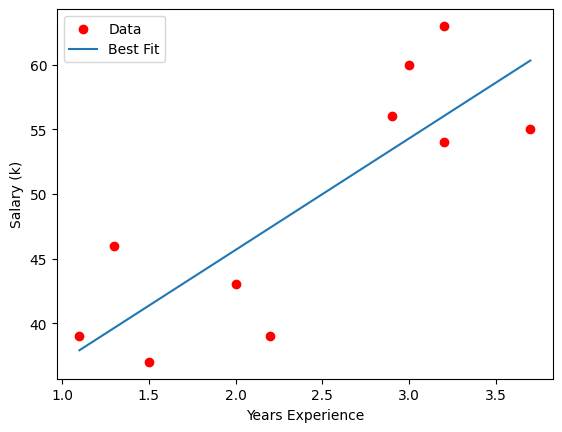

Optimized m: 22.42, Optimized c: 37.90


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Preparation
years_experience = np.array([1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7])
salary_k = np.array([39, 46, 37, 43, 39, 56, 60, 54, 63, 55])

# Normalization (Min-Max Scaling)
X_min, X_max = years_experience.min(), years_experience.max()
X_norm = (years_experience - X_min) / (X_max - X_min)

def compute_cost(X, y, m, c):
    n = len(X)
    y_pred = m * X + c
    return (1/n) * np.sum((y_pred - y)**2)

def gradient_descent_backtracking(X, y, initial_alpha=1.0, rho=0.5, c_param=1e-4, iterations=100):
    m, c = 0.0, 0.0
    n = len(X)
    cost_history = []
    total_backtracks = 0

    for _ in range(iterations):
        y_pred = m * X + c
        error = y_pred - y
        
        # Gradients
        dm = (2/n) * np.dot(error, X)
        dc = (2/n) * np.sum(error)

        # Backtracking Line Search (Armijo Condition)
        alpha = initial_alpha
        current_cost = compute_cost(X, y, m, c)
        
        while True:
            new_m = m - alpha * dm
            new_c = c - alpha * dc
            new_cost = compute_cost(X, y, new_m, new_c)
            
            # Check for sufficient decrease
            if new_cost < current_cost - c_param * alpha * (dm**2 + dc**2):
                m, c = new_m, new_c
                break
            else:
                alpha *= rho
                total_backtracks += 1
        
        cost_history.append(new_cost)

    return m, c, cost_history, total_backtracks

# Execute
m_opt, c_opt, costs, backtracks = gradient_descent_backtracking(X_norm, salary_k)

# Plot Final Fit
plt.scatter(years_experience, salary_k, color='red', label='Data')
plt.plot(years_experience, m_opt * X_norm + c_opt, label='Best Fit')
plt.xlabel('Years Experience')
plt.ylabel('Salary (k)')
plt.legend()
plt.show()

print(f"Optimized m: {m_opt:.2f}, Optimized c: {c_opt:.2f}")

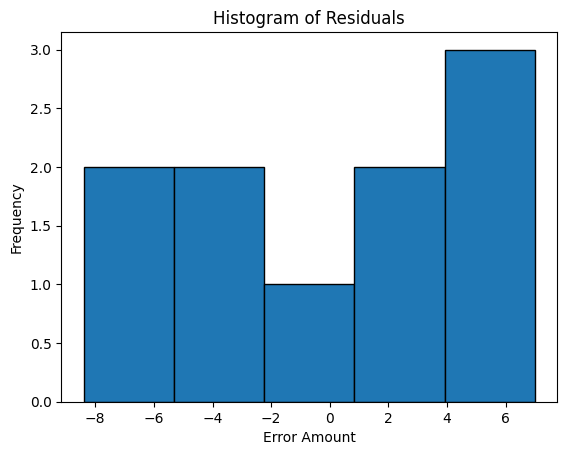

In [10]:
predictions = m_opt * X_norm + c_opt
residuals = salary_k - predictions

plt.hist(residuals, bins=5, edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Error Amount')
plt.ylabel('Frequency')
plt.show()

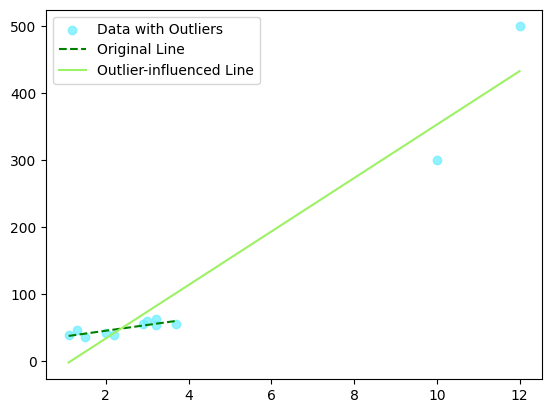

In [23]:
# Add outliers
years_outlier = np.append(years_experience, [10, 12])
salary_outlier = np.append(salary_k, [300, 500])

# Re-normalize and Re-run
X_norm_out = (years_outlier - years_outlier.min()) / (years_outlier.max() - years_outlier.min())
m_out, c_out, _, _ = gradient_descent_backtracking(X_norm_out, salary_outlier)

# Plot Comparison
plt.scatter(years_outlier, salary_outlier, color="#6eeeffbe", label='Data with Outliers')
plt.plot(years_experience, m_opt * X_norm + c_opt, 'g--', label='Original Line')
plt.plot(years_outlier, m_out * X_norm_out + c_out, "#9df165", label='Outlier-influenced Line')
plt.legend()
plt.show()